In [1]:
%load_ext autoreload
%autoreload 2
# Pipeline:
#  Define a neural net
#  Create a dataset to train on. Standard classifier example, or maybe XOR (or both)
#  Create a function script which enables either Cross-entropy or Direction loss function [ESSENTIAL]
#  Training model on the dataset on set of training points (very few -> 100% accuracy) [ESSENTIAL]

## Standard libraries
import numpy as np
import pickle

## Progress bar
from tqdm.auto import tqdm

#ML Libraries
import jax
import torch
import optax

import torch.utils.data as data

# Custom Libraries
from gradient_supervision_package.library.custom_models   import SimpleClassifier, MLP, CNN,  GSPaper, GSPaperNew, GSPaper2, GSPaper3, BagOfWordsClassifier, BagOfWordsClassifierSimple, BagOfWordsClassifierSingle, TextClassifierEmbeddingsSetfit
from gradient_supervision_package.library.custom_datasets import customDataset, genCustomDataset
from gradient_supervision_package.library.custom_datasets import datasets as custom_datasets
from gradient_supervision_package.library.loss_functions import loss_functions
# from gradient_supervision_package.library.knowledge_functions import knowledge_functions
import gradient_supervision_package.library.knowledge_functions as knowledge_functions
from gradient_supervision_package.library.utilities import (visualise_classes, numpy_collate, custom_collate,
                        reduce_dataset, compute_metrics, generate_results, generate_results_ensemble, create_train_state, boundary_filter, save_stats, train_one_epoch, combine_datasets, gen_knowledge)

from matplotlib import pyplot as plt


import numpy as np
import jax.numpy as jnp
from tqdm.auto import tqdm

# FAT Forensics Counterfactual Explainer
import fatf.transparency.predictions.counterfactuals as fatf_cf
from gradient_supervision_package.library.utilities import get_rand_vec, get_unit_vec


/Users/jonathanerskine/miniforge3/envs/sentiment/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
25-May-27 16:06:28 fatf.utils.array.tools INFO     Using numpy's numpy.lib.recfunctions.structured_to_unstructured as fatf.utils.array.tools.structured_to_unstructured and fatf.utils.array.tools.structured_to_unstructured_row.


In [2]:
def optimum_classifier(Z):
        """
        Inputs  | z:      x,y coordinates of data to be classified.
        Outputs | probs:  array of probabilities for each class for input data.
        """
        return np.array([int(z[0]>=0) for z in Z])




X = np.array([(x,x**2) for x in np.linspace(-5,5,10)])
Y = np.array([0]*5+[1]*5)

y_preds = optimum_classifier(X)


In [7]:
K = knowledge_functions.counterfactual_vector_paths(X,Y,classifier=optimum_classifier)

Generating 3 counterfactual samples per observation ...


0it [00:00, ?it/s]

dir [[ 0.1        25.        ]
 [ 0.1        24.90864198]]
delta [[0.        0.       ]
 [2.55      2.5504091]
 [5.1       5.1008182]]
distance [5.1       5.1008182]


ValueError: Incompatible shapes for broadcasting: shapes=[(2, 3, 2), (2, 3)]

In [ ]:
K['origin']

NameError: name 'K' is not defined

In [ ]:
cf_explainer = fatf_cf.CounterfactualExplainer(predictive_function = optimum_classifier,
                                                      dataset = X,
                                                      categorical_indices=[],
                                                      default_numerical_step_size=0.5,
                                                      max_counterfactual_length=1)
cfs = [cf_explainer.explain_instance(x,normalise_distance=True) for x in np.array(X)]

In [ ]:
cfx

[array([ 0., 25.]),
 array([ 0.        , 15.12345679]),
 array([0.        , 7.71604938]),
 array([0.        , 2.77777778]),
 array([0.        , 0.30864198]),
 array([-0.5       ,  0.30864198]),
 array([-0.5       ,  2.77777778]),
 array([-0.5       ,  7.71604938]),
 array([-0.5       , 15.12345679]),
 array([-0.5, 25. ])]

In [ ]:
coords = list(zip(X,cfx))

In [ ]:
coords

[(array([-5., 25.]), array([ 0., 25.])),
 (array([-3.88888889, 15.12345679]), array([ 0.        , 15.12345679])),
 (array([-2.77777778,  7.71604938]), array([0.        , 7.71604938])),
 (array([-1.66666667,  2.77777778]), array([0.        , 2.77777778])),
 (array([-0.55555556,  0.30864198]), array([0.        , 0.30864198])),
 (array([0.55555556, 0.30864198]), array([-0.5       ,  0.30864198])),
 (array([1.66666667, 2.77777778]), array([-0.5       ,  2.77777778])),
 (array([2.77777778, 7.71604938]), array([-0.5       ,  7.71604938])),
 (array([ 3.88888889, 15.12345679]), array([-0.5       , 15.12345679])),
 (array([ 5., 25.]), array([-0.5, 25. ]))]

In [ ]:
[coord[0] for coord in coords[0]]


[np.float64(-5.0), np.float64(0.0)]

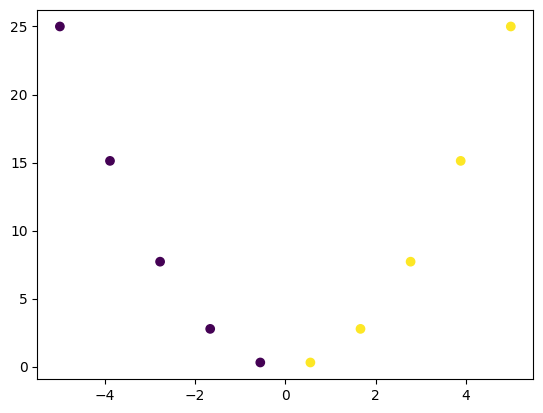

In [ ]:

# test_cf = cf_explainer.explain_instance(X[0],normalise_distance=True)
plt.scatter(X[:,0],X[:,1],c=Y)
# [plt.plot(c_i[0],c_i[1]) for c_i in coord s[0]],[coord[1] for coord in coords[1]])]
# coords_0 = coords[0]


In [ ]:
print(coords_0)

print([coord[0] for coord in coords_0])

(array([-5., 25.]), array([ 0., 25.]))
[np.float64(-5.0), np.float64(0.0)]


In [ ]:


def gen_best_vec(x,cf_explainer):      
  cfs = cf_explainer.explain_instance(np.array(x),normalise_distance=True)
  return get_unit_vec(x,cfs[0][0])


In [ ]:


def counterfactual_vector(dataset, dims = 2, n_vec=3, n_samples=10, max_delta=1.0):
    print(f"Generating {n_vec} counterfactual directions...")
  # Lets generate the nearest point where the classification boundary changes
    # For now, generate the nearest n_vec counterfactuals, and keep the rest the same?
    X = dataset.data.X['vector']
    cf_explainer = fatf_cf.CounterfactualExplainer(predictive_function = dataset.data.optimum_classifier,
                                                      dataset = X,
                                                      categorical_indices=[],
                                                      default_numerical_step_size=0.1)

    #change to ...,1,2 if only using one direction
    # n_vec = 1
    
    directions = np.zeros((len(X),n_vec, 2))
    
    direction_label = -np.ones((len(X),n_vec))
    direction_distance = np.ones((len(X),n_vec))


    for i, x in tqdm(enumerate(X)):

      dir, distance = gen_best_vec(x,cf_explainer)
      
      # single label version
      directions[i,0, :] = dir
      direction_label[i,0] = -1
      direction_distance[i,0] = distance
    return directions, direction_label, direction_distance